# Imports e funcoes auxiliares

In [2]:
#Imports
import numpy as np
import pandas as pd
from statsmodels.tsa.statespace.sarimax import SARIMAX
from pmdarima import auto_arima 
from statsmodels.tsa.stattools import adfuller
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from statsmodels.tools.eval_measures import rmse
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error, mean_absolute_error
import matplotlib.pyplot as plt

#Utilitarios visuais
%matplotlib inline
import warnings
warnings.filterwarnings("ignore")

#Funcao para testar sasonalidade
def adf_test(series, title=""):
    """
    Pass in a time series and an optional title, returns an ADF report
    """
    print(f"Augmented Dickey-Fuller Test: {title}")
    result = adfuller(
        series.dropna(), autolag="AIC"
    )  # .dropna() handles differenced data

    labels = ["ADF test statistic", "p-value", "# lags used", "# observations"]
    out = pd.Series(result[0:4], index=labels)

    for key, val in result[4].items():
        out[f"critical value ({key})"] = val

    print(out.to_string())  # .to_string() removes the line "dtype: float64"

    if result[1] <= 0.05:
        print("Strong evidence against the null hypothesis")
        print("Reject the null hypothesis")
        print("Data has no unit root and is stationary")
    else:
        print("Weak evidence against the null hypothesis")
        print("Fail to reject the null hypothesis")
        print("Data has a unit root and is non-stationary")

#Funcao para checar o erro médio total (CONSTRUIDA APENAS PARA ESTE ARQUIVO)
def total_mean_error(predictions):
    mean_error = []

    for i in range(len(predictions)):
        if df['Normalized'][i] == 0:
            error_value = np.abs((predictions[i]-0.01)/(0.01))*100
            mean_error.append(error_value)
            print(
                f"predição={predictions[i]}, esperado={df['Normalized'][i]}, erro={error_value}%"
            )
        else:
            error_value = np.abs((predictions[i]-df['Normalized'][i])/(df['Normalized'][i]))*100
            mean_error.append(error_value)
            print(
                f"predição={predictions[i]}, esperado={df['Normalized'][i]}, erro={error_value}%"
            )

    aux = 0

    for i in range(len(mean_error)):
        if mean_error[i] > 200:
            aux = aux
        else:
            aux = mean_error[i] + aux

    final_mean = aux/len(mean_error)

    print(f"Erro percentual médio = {final_mean}%")

In [3]:
# Lendo os dados
df = pd.read_excel(
    "/home/henrique/IC-Gasto-Fotovoltaico-main/Controle_Faturamento_2023.xlsx",
    sheet_name="Consumo Médio - Clientes",
)

# Removendo dados desnecessários
df.drop(df.iloc[:, 48:68], inplace=True, axis=1)
df.drop("Nº Cliente", inplace=True, axis=1)
df.drop("Cliente", inplace=True, axis=1)

df = df.head()

#Ajustando indice
df1 = df.transpose()
df = df1.rename(columns=df1.iloc[0])
df.drop("UC", inplace=True, axis=0)
df.dropna(inplace=True)
df.index
dates = np.array(df.index, dtype="datetime64[D]")
idx = pd.DatetimeIndex(dates)
df["idx"] = idx
df.set_index("idx", inplace=True)
df.index.freq = "MS"

# DATA AUGMENTATION

In [4]:
# Duplicando os dados
df = pd.concat([df, df])

In [5]:
#Ajustando o índice para os dados duplicados
new_index = pd.date_range(start=df.index.min(), periods=len(df), freq="MS")
df.index = new_index

df_aug = df

# Modelo com train/test

In [6]:
train = df.iloc[:80]
test = df.iloc[80:]

test = test.astype(float)
train = train.astype(float)

# Modelo utilizado possui parametros obtidos por tentativa e erro
model = SARIMAX(
    train[3003858507].astype(float), order=(5, 0, 7), seasonal_order=(10, 1, 7, 12)
)
results = model.fit()

 This problem is unconstrained.


RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =           30     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f=  7.11915D+00    |proj g|=  3.46744D-01

At iterate    5    f=  6.98536D+00    |proj g|=  3.74554D-02

At iterate   10    f=  6.96872D+00    |proj g|=  1.72380D-02

At iterate   15    f=  6.96539D+00    |proj g|=  1.25647D-02

At iterate   20    f=  6.96125D+00    |proj g|=  7.85802D-03

At iterate   25    f=  6.96052D+00    |proj g|=  9.79360D-03

At iterate   30    f=  6.95971D+00    |proj g|=  1.21105D-02

At iterate   35    f=  6.95944D+00    |proj g|=  4.58670D-03

At iterate   40    f=  6.95923D+00    |proj g|=  4.40456D-03

At iterate   45    f=  6.95896D+00    |proj g|=  1.80343D-03

At iterate   50    f=  6.95879D+00    |proj g|=  3.81283D-03

           * * *

Tit   = total number of iterations
Tnf   = total number of function evaluations
Tnint = total number of segments explored during Cau

In [7]:
#Predicoes
start = len(train)
end = len(train) + len(test) - 1
augmented_predictions = results.predict(
    start=start, end=end, dynamic=False, typ="levels"
).rename("SARIMA Predictions")

augmented_future_predictions = results.predict(
    start=end, end=end + 12, dynamic=False, typ="levels"
).rename("SARIMA Future Predictions")


In [8]:
mape = mean_absolute_percentage_error(test[3003858507], augmented_predictions)
print("MAPE: {:.2f}%".format(mape*100))

MAPE: 115.04%


In [9]:
#Root mean squared error
error = rmse(test[3003858507], augmented_predictions)
print(f'RMSE Error: {error:11.10}')

RMSE Error:  1244.70948


[Text(0.5, 0, ''), Text(0, 0.5, 'Consumo')]

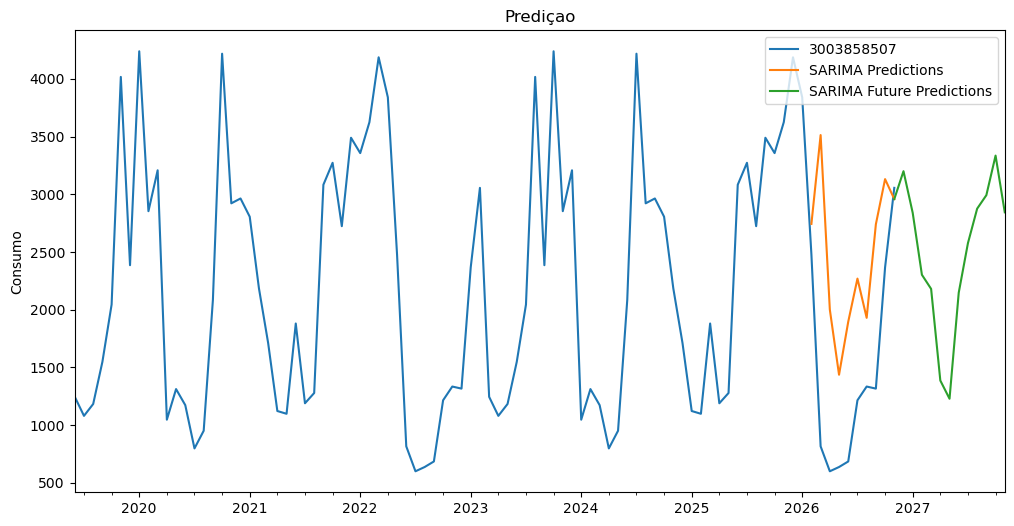

In [10]:
title = "Prediçao"
ylabel = "Consumo"
xlabel = ""

ax = df[3003858507].plot(legend=True, figsize=(12, 6), title=title)
augmented_predictions.plot(legend=True)
augmented_future_predictions.plot(legend=True)
ax.autoscale(axis="x", tight=True)
ax.set(xlabel=xlabel, ylabel=ylabel)

# Modole sem train/test

In [11]:
df.head()

,3003858507,3001084033,3011373971,3001449459,3011504476
2019-06-01,1246.0,7160.0,440.0,960.0,1560.0
2019-07-01,1081.0,6520.0,600.0,920.0,1280.0
2019-08-01,1184.0,6840.0,680.0,1120.0,1360.0
2019-09-01,1549.0,7440.0,760.0,1040.0,1680.0
2019-10-01,2045.0,6920.0,560.0,1120.0,1680.0


In [12]:
auto_arima(
    df[3001084033],
    m=12,
    seasonal=True,
).summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                   90
Model:               SARIMAX(1, 0, 0)   Log Likelihood                -725.871
Date:                Fri, 27 Sep 2024   AIC                           1457.741
Time:                        09:52:33   BIC                           1465.241
Sample:                    06-01-2019   HQIC                          1460.765
                         - 11-01-2026                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept   2727.1944    570.780      4.778      0.000    1608.486    3845.903
ar.L1          0.5713      0.091      6.246      0.000       0.392       0.751
sigma2      5.918e+05    8.5e+04      6.965      0.000    4.25e+05    7.58e+05
===================================================================================
Ljung-Box (L1) (Q):                   0.43   Jarque-Bera (JB):                 1.99
Prob(Q):                              0.51   Prob(JB):                         0.37
Heteroskedasticity (H):               1.05   Skew:                            -0.33
Prob(H) (two-sided):                  0.89   Kurtosis:                         3.31
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [70]:
model = SARIMAX(
    df[3001084033].astype(float), order=(7, 0, 7), seasonal_order=(5, 1, 5, 12)
)
results = model.fit()

RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =           25     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f=  7.23232D+00    |proj g|=  6.63974D-01


 This problem is unconstrained.



At iterate    5    f=  7.01148D+00    |proj g|=  3.10243D-02

At iterate   10    f=  6.99845D+00    |proj g|=  1.28680D-01

At iterate   15    f=  6.98358D+00    |proj g|=  6.12130D-02

At iterate   20    f=  6.97379D+00    |proj g|=  3.20814D-02

At iterate   25    f=  6.96983D+00    |proj g|=  2.49618D-02

At iterate   30    f=  6.96638D+00    |proj g|=  4.46599D-02

At iterate   35    f=  6.96538D+00    |proj g|=  1.32770D-02

At iterate   40    f=  6.96448D+00    |proj g|=  8.78652D-03

At iterate   45    f=  6.96427D+00    |proj g|=  6.22661D-03

At iterate   50    f=  6.96399D+00    |proj g|=  6.51954D-03

           * * *

Tit   = total number of iterations
Tnf   = total number of function evaluations
Tnint = total number of segments explored during Cauchy searches
Skip  = number of BFGS updates skipped
Nact  = number of active bounds at final generalized Cauchy point
Projg = norm of the final projected gradient
F     = final function value

           * * *

   N    Tit     Tn

In [71]:
augmented_predictions = results.predict(
    start=0, end=end, dynamic=False, typ="levels"
).rename("Predições SARIMA")

augmented_future_predictions = results.predict(
    start=0, end=end + 48, dynamic=False, typ="levels"
).rename("Predições SARIMA")

In [72]:
half = df[3001084033].iloc[45:]
half_pred = augmented_predictions.iloc[45:]

mape = mean_absolute_percentage_error(half, half_pred)
print("MAPE: {:.2f}%".format(mape*100))

MAPE: 10.71%


In [52]:
error = rmse(half, half_pred)
print(f'RMSE Error: {error:11.10}')

RMSE Error:  767.967693


In [53]:
mae = mean_absolute_error(half, half_pred)
print("MAE: {:.2f}".format(mae))

MAE: 580.49


In [54]:
wmape = mean_absolute_percentage_error(half, half_pred, sample_weight=half)
print("WMAPE: {:.2f}%".format(wmape*100))

WMAPE: 9.17%


[Text(0.5, 0, ''), Text(0, 0.5, 'Consumo')]

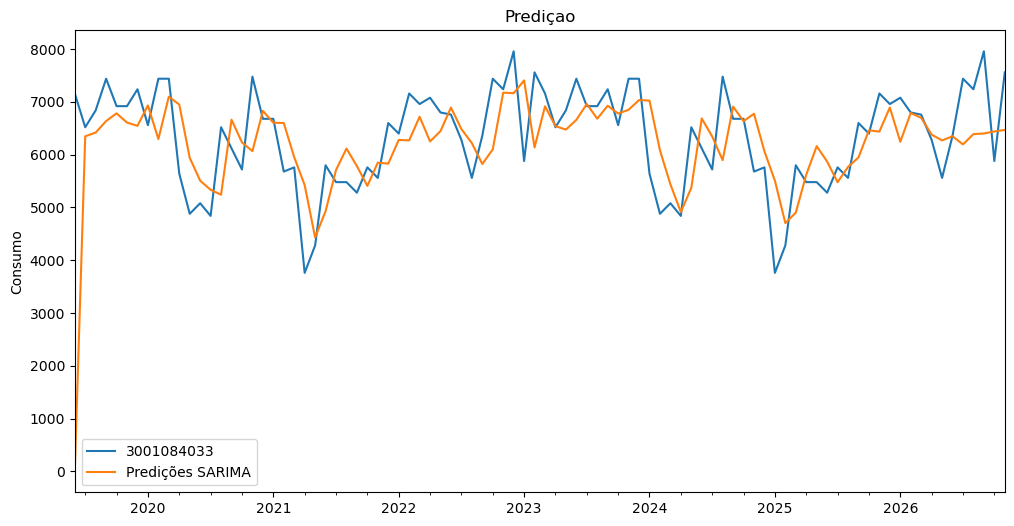

In [68]:
title = "Prediçao"
ylabel = "Consumo"
xlabel = ""

ax = df[3001084033].plot(figsize=(12, 6), title=title,legend=True)
augmented_predictions.plot(legend=True)
ax.autoscale(axis="x", tight=True)
ax.set(xlabel=xlabel, ylabel=ylabel)
#plt.savefig("SARIMAAugmentMDPredial1.png")

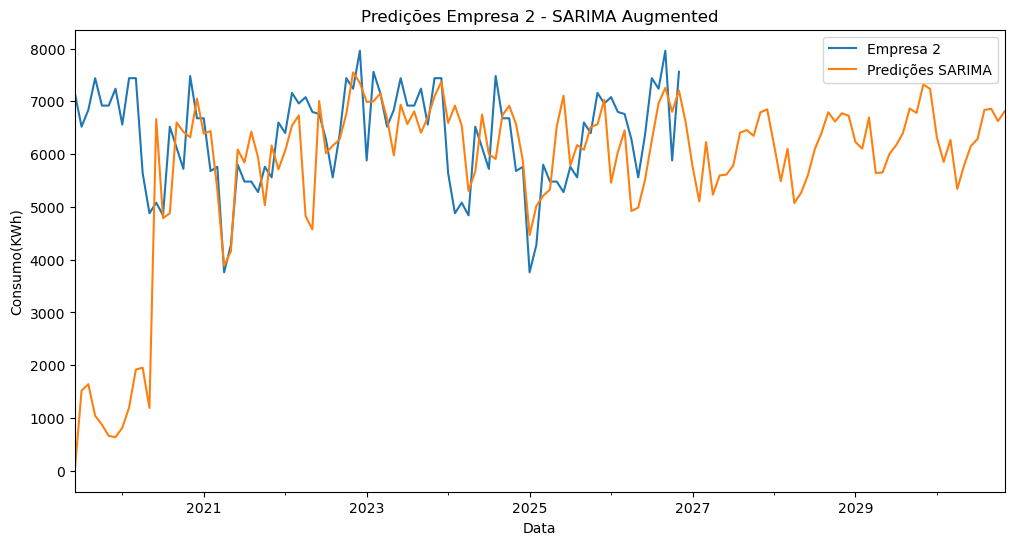

In [74]:
title = "Predições Empresa 2 - SARIMA Augmented"
ylabel = "Consumo(KWh)"
xlabel = "Data"

ax = df[3001084033].plot(figsize=(12, 6), title=title,legend=True, label="Empresa 2")
augmented_future_predictions.plot(legend=True)
ax.autoscale(axis="x", tight=True)
ax.set(xlabel=xlabel, ylabel=ylabel)
plt.savefig("SARIMA Augment - Empresa2Pred.png")

# Normalizacao dos dados (Entre 0 e 1)

In [20]:
#Ajustando os dados para a normalizacao
values = df[3003858507].values
values = values.reshape((len(values), 1))

#Normalizacao
scaler = MinMaxScaler(feature_range=(0, 1))
scaler = scaler.fit(values)
df_normalized = scaler.transform(values)

In [21]:
#Salvando os dados em uma coluna
df["Normalized"] = df_normalized

In [22]:
auto_arima(
    df["Normalized"],
    m=12,
    seasonal=True,
).summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                      
==========================================================================================
Dep. Variable:                                  y   No. Observations:                   90
Model:             SARIMAX(3, 0, 1)x(0, 0, 1, 12)   Log Likelihood                  14.041
Date:                            Fri, 27 Sep 2024   AIC                            -14.081
Time:                                    09:53:28   BIC                              3.417
Sample:                                06-01-2019   HQIC                            -7.025
                                     - 11-01-2026                                         
Covariance Type:                              opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      0.0788      0.021      3.701      0.000       0.037       0.121
ar.L1          1.3871      0.103     13.494      0.000       1.186       1.589
ar.L2         -0.3260      0.167     -1.947      0.051      -0.654       0.002
ar.L3         -0.2433      0.111     -2.188      0.029      -0.461      -0.025
ma.L1         -0.9634      0.079    -12.269      0.000      -1.117      -0.809
ma.S.L12       0.0641      0.188      0.342      0.732      -0.304       0.432
sigma2         0.0412      0.007      5.725      0.000       0.027       0.055
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):                 1.58
Prob(Q):                              0.98   Prob(JB):                         0.45
Heteroskedasticity (H):               0.81   Skew:                             0.32
Prob(H) (two-sided):                  0.56   Kurtosis:                         3.06
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

# Treino com train/test

In [23]:
train = df.iloc[:80]
test = df.iloc[80:]

test = test.astype(float)
train = train.astype(float)

#Modelo utilizado possui parametros obtidos por tentativa e erro
model = SARIMAX(train["Normalized"], order=(3, 0, 1), seasonal_order=(5, 1, 1, 12))
results = model.fit()

RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =           11     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f=  2.10095D-01    |proj g|=  2.70687D-01


 This problem is unconstrained.



At iterate    5    f=  8.71138D-02    |proj g|=  3.86136D-02

At iterate   10    f=  8.07126D-02    |proj g|=  1.60791D-02

At iterate   15    f=  7.18667D-02    |proj g|=  4.70499D-02

At iterate   20    f=  5.70417D-02    |proj g|=  3.35074D-02

At iterate   25    f=  5.44988D-02    |proj g|=  1.07634D-02

At iterate   30    f=  5.30786D-02    |proj g|=  2.77549D-02

At iterate   35    f=  5.26457D-02    |proj g|=  1.89507D-02

At iterate   40    f=  5.14848D-02    |proj g|=  1.36715D-02

At iterate   45    f=  5.06509D-02    |proj g|=  1.68844D-02

At iterate   50    f=  4.99970D-02    |proj g|=  5.48428D-03

           * * *

Tit   = total number of iterations
Tnf   = total number of function evaluations
Tnint = total number of segments explored during Cauchy searches
Skip  = number of BFGS updates skipped
Nact  = number of active bounds at final generalized Cauchy point
Projg = norm of the final projected gradient
F     = final function value

           * * *

   N    Tit     Tn

In [24]:
#Predicoes
start = len(train)
end = len(train) + len(test) - 1
normalized_predictions = results.predict(
    start=start, end=end, dynamic=False, typ="levels"
).rename("SARIMA Predictions")

normalized_future_predictions = results.predict(
    start=end, end=end + 44, dynamic=False, typ="levels"
).rename("SARIMA Future Predictions")

In [25]:
#error = rmse(test["Normalized"], normalized_predictions)
#print(f'RMSE Error: {error:11.10}')
# Não funciona muito bem com numeros normalizados

[Text(0.5, 0, ''), Text(0, 0.5, 'Consumo')]

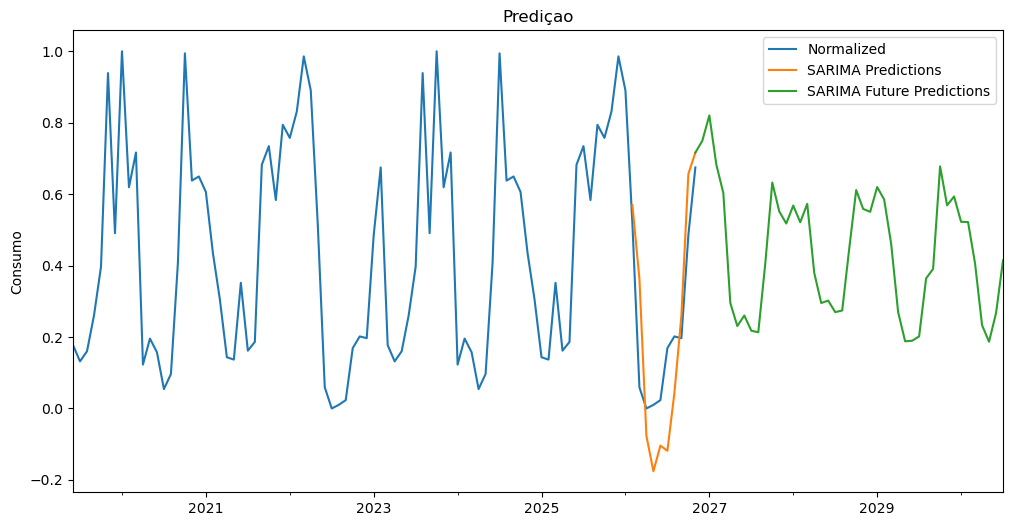

In [26]:
title = "Prediçao"
ylabel = "Consumo"
xlabel = ""

ax = df["Normalized"].plot(legend=True, figsize=(12, 6), title=title)
normalized_predictions.plot(legend=True)
normalized_future_predictions.plot(legend=True)
ax.autoscale(axis="x", tight=True)
ax.set(xlabel=xlabel, ylabel=ylabel)

In [27]:
# Lendo os dados (Para remover retornar o dataset ao estado original)
df = pd.read_excel(
    "/home/henrique/IC-Gasto-Fotovoltaico-main/Controle_Faturamento_2023.xlsx",
    sheet_name="Consumo Médio - Clientes",
)

df.drop(df.iloc[:, 48:68], inplace=True, axis=1)
df.drop("Nº Cliente", inplace=True, axis=1)
df.drop("Cliente", inplace=True, axis=1)

df = df.head()

df1 = df.transpose()
df = df1.rename(columns=df1.iloc[0])
df.drop("UC", inplace=True, axis=0)
df.dropna(inplace=True)

df.index
dates = np.array(df.index, dtype="datetime64[D]")
idx = pd.DatetimeIndex(dates)
df["idx"] = idx
df.set_index("idx", inplace=True)
df.index.freq = "MS"

df = pd.concat([df, df])

new_index = pd.date_range(start=df.index.min(), periods=len(df), freq="MS")

df.index = new_index

In [28]:
values = df[3001084033].values
values = values.reshape((len(values), 1))

scaler = MinMaxScaler(feature_range=(0, 1))
scaler = scaler.fit(values)

df_normalized = scaler.transform(values)

df["Normalized"] = df_normalized

In [29]:
auto_arima(
    df["Normalized"],
    m=12,
    seasonal=True,
).summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                   90
Model:               SARIMAX(1, 0, 0)   Log Likelihood                  24.986
Date:                Fri, 27 Sep 2024   AIC                            -43.972
Time:                        09:53:38   BIC                            -36.472
Sample:                    06-01-2019   HQIC                           -40.947
                         - 11-01-2026                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      0.2676      0.056      4.781      0.000       0.158       0.377
ar.L1          0.5682      0.091      6.229      0.000       0.389       0.747
sigma2         0.0335      0.005      6.984      0.000       0.024       0.043
===================================================================================
Ljung-Box (L1) (Q):                   0.39   Jarque-Bera (JB):                 2.00
Prob(Q):                              0.53   Prob(JB):                         0.37
Heteroskedasticity (H):               1.05   Skew:                            -0.33
Prob(H) (two-sided):                  0.89   Kurtosis:                         3.30
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [30]:
train = df.iloc[:80]
test = df.iloc[80:]

test = test.astype(float)
train = train.astype(float)

model = SARIMAX(train["Normalized"], order=(3, 1, 1), seasonal_order=(5, 1, 1, 12))
results = model.fit()

 This problem is unconstrained.


RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =           11     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f= -2.17109D-02    |proj g|=  6.81853D-01

At iterate    5    f= -1.09270D-01    |proj g|=  3.00149D-01

At iterate   10    f= -1.24597D-01    |proj g|=  4.57843D-01

At iterate   15    f= -1.34790D-01    |proj g|=  1.66191D-01

At iterate   20    f= -1.44942D-01    |proj g|=  1.91693D-01

At iterate   25    f= -1.65863D-01    |proj g|=  5.41907D-01

At iterate   30    f= -1.76807D-01    |proj g|=  5.38438D-02

At iterate   35    f= -1.85859D-01    |proj g|=  2.69634D-02

At iterate   40    f= -1.87687D-01    |proj g|=  2.08936D-01

At iterate   45    f= -1.89342D-01    |proj g|=  6.99698D-03

At iterate   50    f= -1.89491D-01    |proj g|=  1.31037D-02

           * * *

Tit   = total number of iterations
Tnf   = total number of function evaluations
Tnint = total number of segments explored during Cau

In [31]:
start = len(train)
end = len(train) + len(test) - 1
normalized_predictions = results.predict(
    start=0, end=end, dynamic=False, typ="levels"
).rename("SARIMA Predictions")

normalized_future_predictions = results.predict(
    start=end, end=end + 89, dynamic=False, typ="levels"
).rename("SARIMA Future Predictions")

In [32]:
values = normalized_predictions.values
values = values.reshape((len(values), 1))

inversed = scaler.inverse_transform(values)

df['SARIMA Predictions (Denormalized)'] = inversed

In [33]:
values = normalized_future_predictions.values
values = values.reshape((len(values), 1))

inversed = scaler.inverse_transform(values)

df['SARIMA Future Predictions (Denormalized)'] = inversed
#É necessario ajustar o indice apos a normalizacao

In [34]:
error = rmse(df['SARIMA Predictions (Denormalized)'], df[3001084033])
print(f'RMSE Error: {error:11.10}')

RMSE Error: 1002.733365


[Text(0.5, 0, ''), Text(0, 0.5, 'Consumo')]

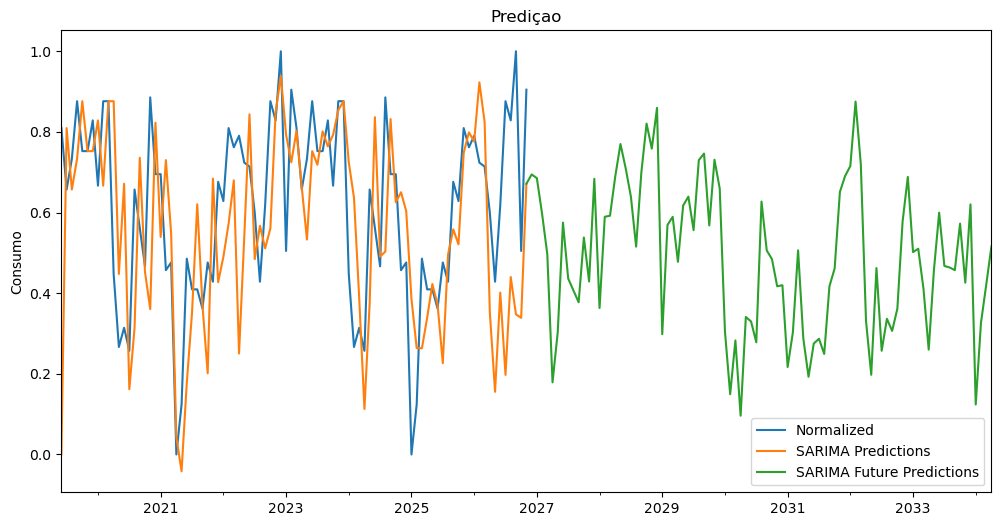

In [35]:
title = "Prediçao"
ylabel = "Consumo"
xlabel = ""

ax = df["Normalized"].plot(legend=True, figsize=(12, 6), title=title)
normalized_predictions.plot(legend=True)
normalized_future_predictions.plot(legend=True)
ax.autoscale(axis="x", tight=True)
ax.set(xlabel=xlabel, ylabel=ylabel)

[Text(0.5, 0, ''), Text(0, 0.5, 'Consumo')]

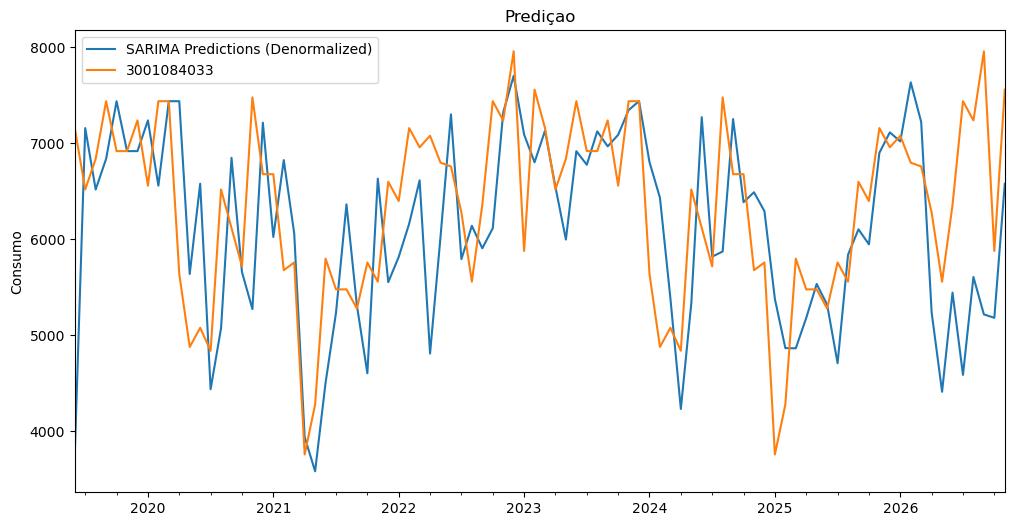

In [36]:
title = "Prediçao"
ylabel = "Consumo"
xlabel = ""

ax = df["SARIMA Predictions (Denormalized)"].plot(legend=True, figsize=(12, 6), title=title)
df[3001084033].plot(legend=True)
ax.autoscale(axis="x", tight=True)
ax.set(xlabel=xlabel, ylabel=ylabel)